In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 1. Load dataset
file_path = "C:\\Users\\DELL\\Downloads\\pl-tables-1993-2024.csv"
df = pd.read_csv(file_path)

In [6]:
# 2. Basic Info
print("Shape of dataset:", df.shape)
print("\nData types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())

Shape of dataset: (646, 12)

Data types:
 season_end_year     int64
team               object
position            int64
played              int64
won                 int64
drawn               int64
lost                int64
gf                  int64
ga                  int64
gd                  int64
points              int64
notes              object
dtype: object

First 5 rows:
    season_end_year            team  position  played  won  drawn  lost  gf  \
0             1993  Manchester Utd         1      42   24     12     6  67   
1             1993     Aston Villa         2      42   21     11    10  57   
2             1993    Norwich City         3      42   21      9    12  61   
3             1993       Blackburn         4      42   20     11    11  68   
4             1993             QPR         5      42   17     12    13  63   

   ga  gd  points                                 notes  
0  31  36      84  → Champions League via league finish  
1  40  17      74          → UE

In [8]:
# 3. Missing values
print("\nMissing Values:\n", df.isnull().sum())



Missing Values:
 season_end_year      0
team                 0
position             0
played               0
won                  0
drawn                0
lost                 0
gf                   0
ga                   0
gd                   0
points               0
notes              320
dtype: int64


In [10]:
# 4. Duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())


Duplicate rows: 0


In [12]:
# 5. Summary statistics
print("\nNumeric Summary:\n", df.describe())
print("\nCategorical Summary:\n", df.describe(include=['object']))


Numeric Summary:
        season_end_year    position      played         won       drawn  \
count       646.000000  646.000000  646.000000  646.000000  646.000000   
mean       2008.365325   10.602167   38.408669   14.283282    9.842105   
std           9.302311    5.840351    1.212411    5.741345    2.956505   
min        1993.000000    1.000000   38.000000    1.000000    2.000000   
25%        2000.000000    6.000000   38.000000   10.000000    8.000000   
50%        2008.000000   11.000000   38.000000   13.000000   10.000000   
75%        2016.000000   16.000000   38.000000   18.000000   12.000000   
max        2024.000000   22.000000   42.000000   32.000000   18.000000   

             lost          gf          ga          gd      points  
count  646.000000  646.000000  646.000000  646.000000  646.000000  
mean    14.283282   51.577399   51.577399    0.000000   52.654799  
std      5.401573   15.195452   13.035291   24.952482   16.499190  
min      0.000000   20.000000   15.000000 

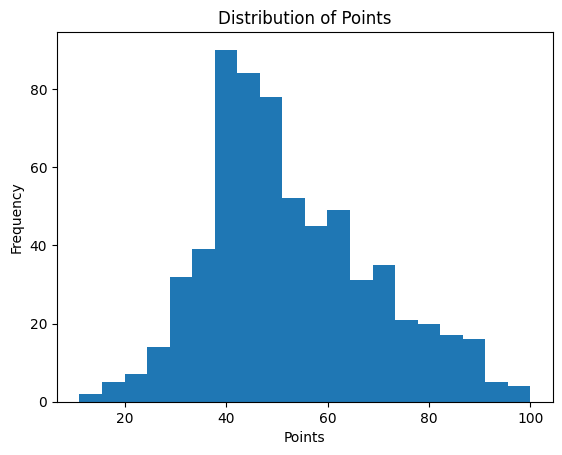

In [14]:
# 6. Univariate Plots
plt.hist(df['points'], bins=20)
plt.title("Distribution of Points")
plt.xlabel("Points")
plt.ylabel("Frequency")
plt.show()


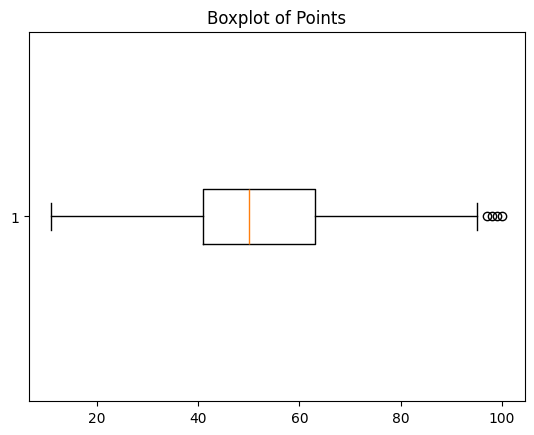

In [16]:
plt.boxplot(df['points'], vert=False)
plt.title("Boxplot of Points")
plt.show()


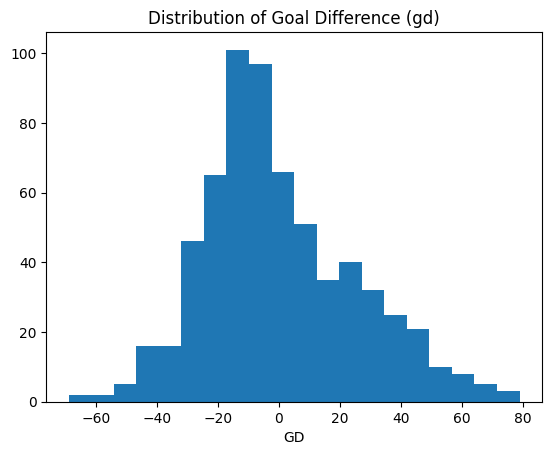

In [18]:
plt.hist(df['gd'], bins=20)
plt.title("Distribution of Goal Difference (gd)")
plt.xlabel("GD")
plt.show()

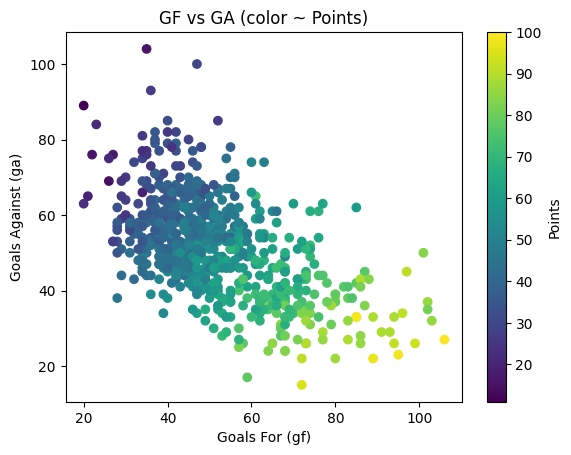

In [20]:
# 7. Bivariate Plot
plt.scatter(df['gf'], df['ga'], c=df['points'], cmap='viridis')
plt.colorbar(label="Points")
plt.xlabel("Goals For (gf)")
plt.ylabel("Goals Against (ga)")
plt.title("GF vs GA (color ~ Points)")
plt.show()


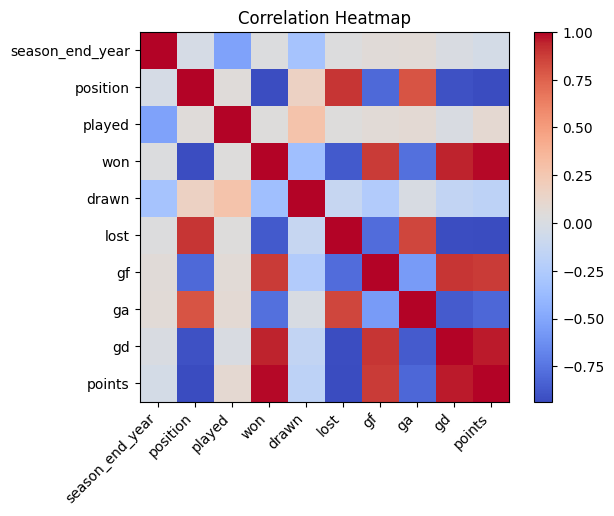

In [22]:
# 8. Correlation Heatmap
corr = df.corr(numeric_only=True)
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
plt.yticks(range(len(corr.columns)), corr.columns)
plt.title("Correlation Heatmap")
plt.show()


In [24]:
# 9. Champions (teams finishing 1st)
champions = df[df['position'] == 1]['team'].value_counts()
print("\nTop Champions:\n", champions.head(10))


Top Champions:
 team
Manchester Utd     13
Manchester City     8
Chelsea             5
Arsenal             3
Blackburn           1
Leicester City      1
Liverpool           1
Name: count, dtype: int64


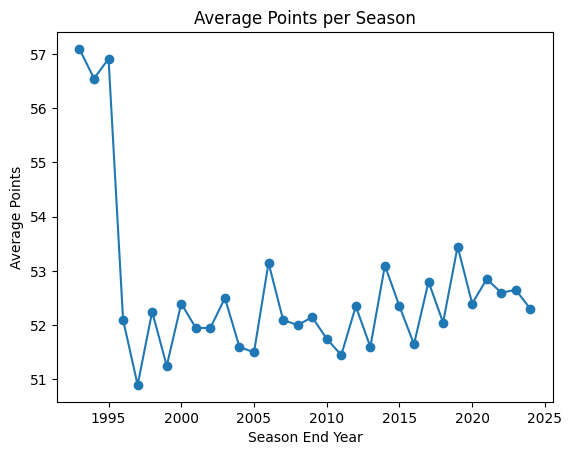

In [26]:
# 10. Season-wise average points
avg_points = df.groupby('season_end_year')['points'].mean()
plt.plot(avg_points.index, avg_points.values, marker='o')
plt.title("Average Points per Season")
plt.xlabel("Season End Year")
plt.ylabel("Average Points")
plt.show()

In [28]:
# 11. Outlier Detection (IQR)
Q1 = df['points'].quantile(0.25)
Q3 = df['points'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR
outliers = df[(df['points'] < lower) | (df['points'] > upper)]
print("\nOutliers in Points:\n", outliers[['season_end_year','team','points']].head())


Outliers in Points:
      season_end_year             team  points
506             2018  Manchester City     100
526             2019  Manchester City      98
527             2019        Liverpool      97
546             2020        Liverpool      99
